
# 폐렴진단 모델 학습
---



In [ ]:
# 참고
# https://www.kaggle.com/faizunnabi/diagnose-pneumonia

In [ ]:
# tensorflow 버전 확인

import tensorflow as tf

tf.__version__

'2.3.0'

In [5]:
# 내 구글 드라이버에 연동

from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# 1.먼저 본인의 Kaggle 계정에서 API Token 을 다운받습니다.(kaggle.json)
# 2.Kaggle API를 설치합니다.
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# 3.kaggle.json 파일을 VM에 업로드 합니다.
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"briansong","key":"247d332863eec5370ba5dc718656d51e"}'}

In [ ]:
# 4.파일이 재대로 업로드 됐는지 확인
!ls -1ha kaggle.json

ls: cannot access 'kaggle.json': No such file or directory


In [ ]:
# 5.Kaggle API 가 Token을 사용하게 하기 위해 kaggle.json 파일을 ~/.kaggle로 이동 시킵니다.
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
# 6. Permission Warning 이 일어나지 않도록 권한 부여
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# dataset URL : https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia
# 7.Kaggle 에서 chest-xray dataset을 다운 받기 위해 API Command 를 복사해서 가져옵니다.
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

100% 2.29G/2.29G [00:28<00:00, 50.7MB/s]
100% 2.29G/2.29G [00:29<00:00, 84.8MB/s]


In [ ]:
# 압축파일 해제
from zipfile import ZipFile

with ZipFile('chest-xray-pneumonia.zip') as z:
    z.extractall()

In [ ]:
# dataset을 내 구글 드라이버로 이동시킴
!mv chest_xray /content/gdrive/My\ Drive/CV/Diagnose\ Pneumonia/

In [ ]:
# 다운로드 받았던 파일 제거
!rm chest-xray-pneumonia.zip

In [6]:
# 구글 드라이버로 이동된 dataset 확인
!ls /content/gdrive/My\ Drive/CV/Diagnose\ Pneumonia/chest_xray/chest_xray/test

NORMAL	PNEUMONIA


In [7]:
# 구글 드라이버로 이동된 dataset 확인
!ls /content/gdrive/My\ Drive/CV/Diagnose\ Pneumonia/chest_xray/chest_xray/train

NORMAL	PNEUMONIA


In [8]:
# 필요한 패키지와 모듈을 불러옴

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [9]:
# train dataset 에서 정상적인 사람과 폐렴에 걸린 사람의 폐사진을 각각 가져옵니다.

total_images_train_normal = os.listdir('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train/NORMAL/')
total_images_train_pneumonia = os.listdir('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train/PNEUMONIA/')

In [11]:
# total_images_train_normal 객체 타입

type(total_images_train_normal)

list

In [12]:
# total_images_train_normal 객체 데이터 수

len(total_images_train_normal)

1342

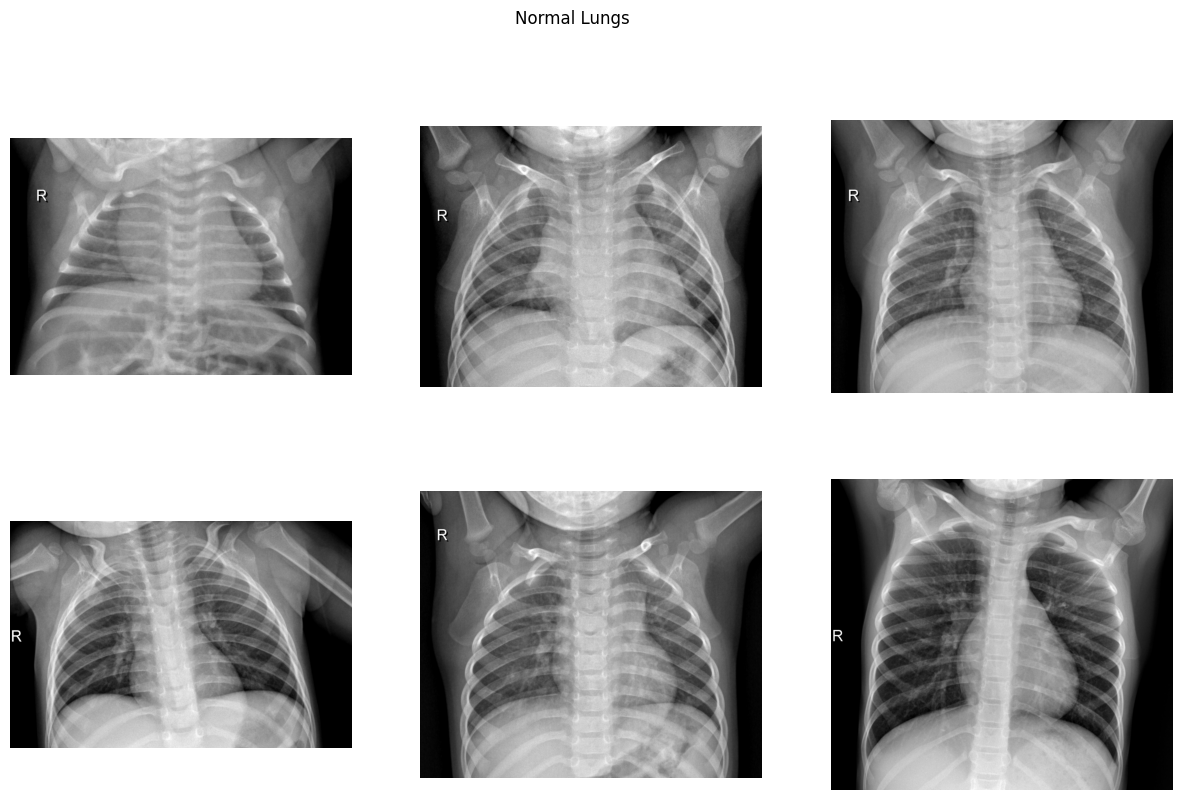

In [10]:
# 정상적인 사람의 폐사진 샘플 6장을 보여줍니다.

sample_normal = random.sample(total_images_train_normal,6)
f,ax = plt.subplots(2,3,figsize=(15,9))

for i in range(0,6):
    im = cv2.imread('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train/NORMAL/'+sample_normal[i])
    ax[i//3,i%3].imshow(im)
    ax[i//3,i%3].axis('off')
f.suptitle('Normal Lungs')
plt.show()

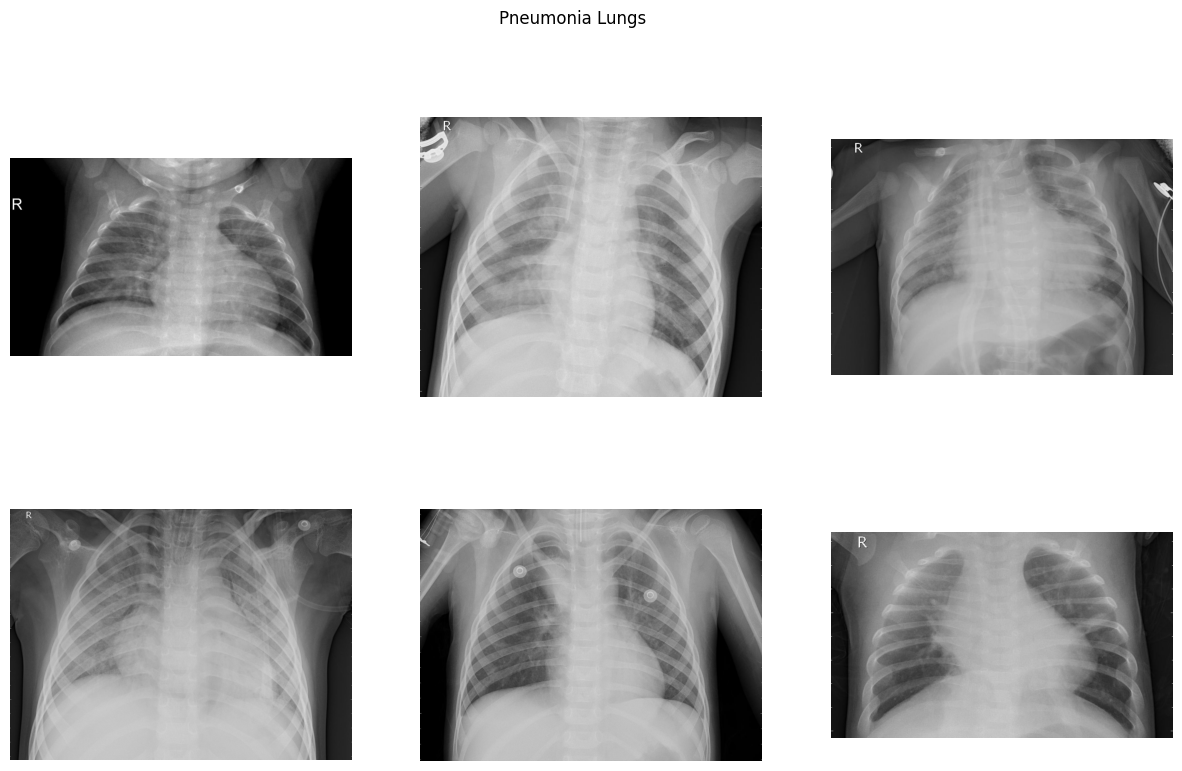

In [13]:
# 폐렴에 걸린 사람의 폐사진 샘플 6장을 보여줍니다.

sample_pneumonia = random.sample(total_images_train_pneumonia,6)
f,ax = plt.subplots(2,3,figsize=(15,9))

for i in range(0,6):
    im = cv2.imread('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train/PNEUMONIA/'+sample_pneumonia[i])
    ax[i//3,i%3].imshow(im)
    ax[i//3,i%3].axis('off')
f.suptitle('Pneumonia Lungs')
plt.show()

In [14]:
# 하이퍼파라미터 설정

image_height = 150  # 이미지 높이
image_width = 150   # 이미지 넓이
batch_size = 10     # batch size
no_of_epochs  = 30  # training 횟수

In [15]:
# create model(모델을 만듭니다)

model = Sequential()
model.add(Conv2D(32,(3,3),input_shape=(image_height,image_width,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 146, 146, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 73, 73, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 73, 73, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 69, 69, 64)        36928     
                                                        

In [16]:
# ImageDataGenerator 클래스를 통해 train_datagen 인스턴스를 만듭니다.
train_datagen = ImageDataGenerator(rescale=1./255,     # 픽셀 값을 0~1 범위로 변환
                                   rotation_range=15,  # 15도까지 회전
                                   shear_range=0.2,    # 20%까지 기울임
                                   zoom_range=0.2      # 20%까지 확대
                                   )

In [17]:
# ImageDataGenerator 클래스를 통해 val_datagen 인스턴스를 만듭니다
val_datagen = ImageDataGenerator(rescale=1./255)       # 픽셀 값을 0~1 범위로 변환

In [18]:
# train_datagen 인스턴스를 통해 trin dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 training_set 객체를 생성한다.
training_set = train_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train',
                                                 target_size=(image_width, image_height),
                                                 batch_size=batch_size,
                                                 class_mode='binary')

Found 5216 images belonging to 2 classes.


In [19]:
# val_datagen 인스턴스를 통해 test dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 test_set 객체를 생성한다.
test_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/test',
                                            target_size=(image_width, image_height),
                                            batch_size=batch_size,
                                            class_mode='binary')

Found 624 images belonging to 2 classes.


In [20]:
# val_datagen 인스턴스를 통해 val dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 val_set 객체를 생성한다.
val_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/val',
                                            target_size=(image_width, image_height),
                                            batch_size=1,
                                            shuffle=False,
                                            class_mode='binary')

Found 16 images belonging to 2 classes.


In [22]:
# 콜백함수 정의
# 모델 학습시 가장 최신의 최고 모델을 저장하는 인스턴스를 정의

modelCheckpoint = ModelCheckpoint('diagnose_pneumonia_model.h5', save_best_only=True)

In [23]:
# 콜백함수 정의
# 모델 학습시 정확도를 모니터링하여 조기에 학습을 종료시키는 인스턴스 정의

monitor_val_acc = EarlyStopping(monitor='val_accuracy', patience=5)

In [ ]:
# model training(모델을 학습시킵니다)
history = model.fit_generator(training_set,
                    steps_per_epoch=5216//batch_size,
                    epochs=no_of_epochs,
                    validation_data=test_set,
                    validation_steps=624//batch_size,
                    callbacks=[monitor_val_acc, modelCheckpoint]
                   )

<ipython-input-14-5c1f21344004>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(training_set,


Epoch 1/30
521/521 [==============================] - 660s 1s/step - loss: 0.5710 - accuracy: 0.7443 - val_loss: 0.7070 - val_accuracy: 0.6129
Epoch 2/30
521/521 [==============================] - 85s 163ms/step - loss: 0.4692 - accuracy: 0.7876 - val_loss: 0.5902 - val_accuracy: 0.6790
Epoch 3/30
521/521 [==============================] - 88s 169ms/step - loss: 0.4396 - accuracy: 0.7989 - val_loss: 0.5416 - val_accuracy: 0.7242
Epoch 4/30
521/521 [==============================] - 85s 164ms/step - loss: 0.3798 - accuracy: 0.8450 - val_loss: 0.4394 - val_accuracy: 0.7823
Epoch 5/30
521/521 [==============================] - 88s 168ms/step - loss: 0.2861 - accuracy: 0.8792 - val_loss: 0.2978 - val_accuracy: 0.8758
Epoch 6/30
521/521 [==============================] - 85s 163ms/step - loss: 0.2410 - accuracy: 0.9028 - val_loss: 0.3303 - val_accuracy: 0.8532
Epoch 7/30
521/521 [==============================] - 88s 168ms/step - loss: 0.2178 - accuracy: 0.9101 - val_loss: 0.3078 - val_accu

In [ ]:
# 전체 학습된 모델을 H5파일로 저장하고, 그 파일을 내 구글 드라이버로 이동시킴
!mv diagnose_pneumonia_model.h5 /content/gdrive/My\ Drive/CV/Diagnose\ Pneumonia/

In [ ]:
# model evaluate(모델을 평가해 봅니다)
score = model.evaluate(test_set, steps=624//batch_size, verbose=1)
print('Val loss:', score[0])
print('Val accuracy:', score[1]*100)

62/62 [==============================] - 6s 97ms/step - loss: 0.3686 - accuracy: 0.8548
Val loss: 0.3686389625072479
Val accuracy: 85.48387289047241


In [ ]:
# test_set 이 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.
print(test_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


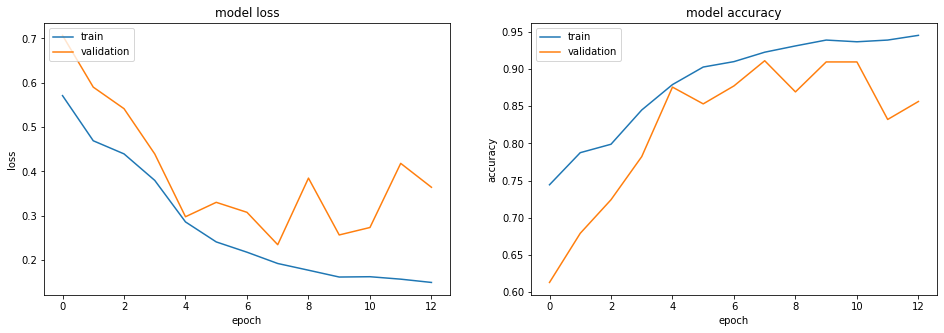

In [ ]:
# 모델에 대한 훈련 데이터 셋과 검증용 데이터 셋의 손실값(loss), 정확도(accuracy)를 시각화

plt.figure(figsize=(16,5))

# 만들어진 모델에 대해 train dataset과 validation dataset의 loss 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

# 만들어진 모델에 대해 train dataset과 validation dataset의 accuracy 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [25]:
# 저장해 뒀던 모델을 불러옵니다.

from tensorflow.keras.models import load_model

model = load_model('gdrive/My Drive/CV/Diagnose Pneumonia/diagnose_pneumonia_model.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 146, 146, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 73, 73, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 73, 73, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 69, 69, 64)        36928     
                                                        

In [26]:
# 학습된 모델에 val_set 객체가 만들어낸 이미지로 분류 예측을 수행해 보자.
predictions = model.predict(val_set, steps=16, verbose=1)

16/16 [==============================] - 16s 560ms/step


In [27]:
# 예측 결과 객체 predictions shape 확인
predictions.shape

(16, 1)

In [28]:
# 예측 결과 확인
predictions

array([[0.7094597 ],
       [0.5348588 ],
       [0.23154846],
       [0.83332115],
       [0.98341817],
       [0.9487347 ],
       [0.3363725 ],
       [0.02327376],
       [0.99761   ],
       [0.99450207],
       [0.90449005],
       [0.9086135 ],
       [0.97572815],
       [0.994443  ],
       [0.98599225],
       [0.98664063]], dtype=float32)

In [29]:
# val_set 이 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.
print(val_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


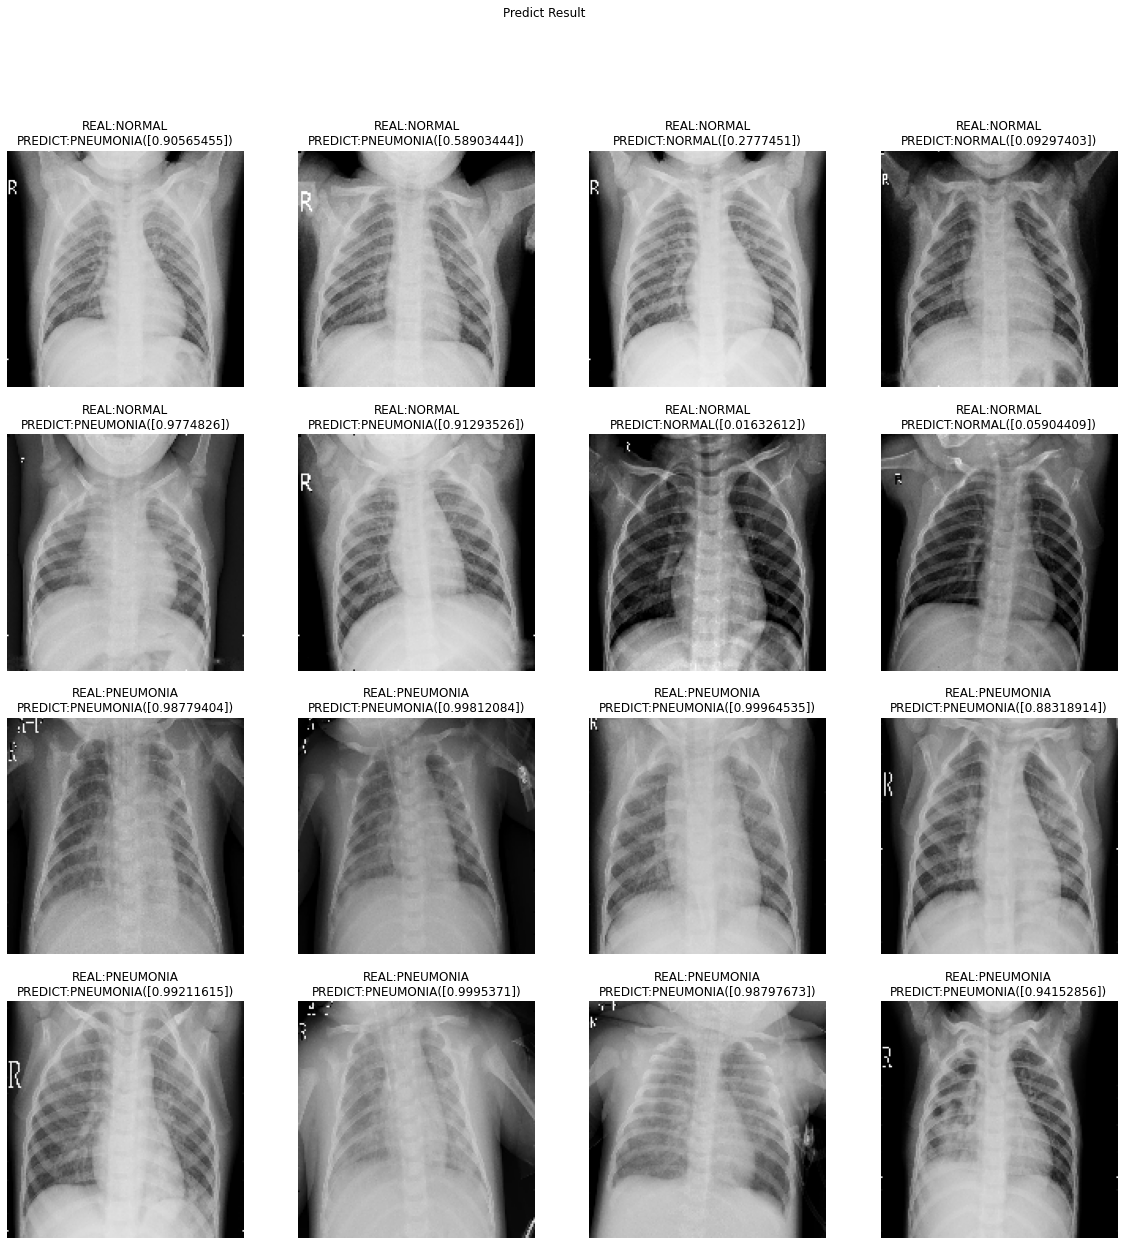

In [ ]:
# Predict Result(val_set 가 만들어 낸 이미지를 우리가 만든 모델을 통해 예측한 결과를 보여줍니다.)
f,ax = plt.subplots(4,4,figsize=(20,20))

for i in range(len(predictions)):
    image, label = val_set.next()                                  # val_set 이 만들어 낸 이미지를 하나씩 꺼내온다
    real_class = 'NORMAL' if int(label) == 0 else 'PNEUMONIA'      # val_set 이 만들어 낸 이미지의 label name 을 가져옴
    ax[i//4,i%4].imshow(image[0])                                  # val_set 이 만들어 낸 이미지를 보여줌
    ax[i//4,i%4].axis('off')

    pred_class = 'PNEUMONIA' if predictions[i] > 0.5 else 'NORMAL' # val_set 이 만들어 낸 이미지를 모델을 통해 예측한 결과 값의 label name
    pred_prob = predictions[i]                                     # val_set 이 만들어 낸 이미지를 모델을 통해 예측한 결과(확률값)
    ax[i//4,i%4].set_title('REAL:' + real_class + '\nPREDICT:' + pred_class + '(' + str(pred_prob) + ')')   # title 에 실제값과 모델에 의해 예측된 예측값을 함께 보여준다.

f.suptitle('Predict Result')

plt.show()

# 앞의 모델을 개선해 보자.

In [ ]:
# 필요한 패키지와 모듈을 불러옴
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# 하이퍼파라미터 설정
image_height = 150  # 이미지 높이
image_width = 150   # 이미지 넓이
batch_size = 10     # batch size
no_of_epochs  = 30  # training 횟수

In [ ]:
# create model(모델을 만듭니다)
model2 = Sequential()
model2.add(Conv2D(32,(3,3),input_shape=(image_height,image_width,3),activation='relu', kernel_initializer='he_normal'))
model2.add(Conv2D(32,(3,3),activation='relu', kernel_initializer='he_normal'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.3))
model2.add(Conv2D(64,(3,3),activation='relu', kernel_initializer='he_normal'))
model2.add(Conv2D(64,(3,3),activation='relu', kernel_initializer='he_normal'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.3))
model2.add(Conv2D(128,(3,3),activation='relu', kernel_initializer='he_normal'))
model2.add(Conv2D(128,(3,3),activation='relu', kernel_initializer='he_normal'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.3))
model2.add(Flatten())
model2.add(Dense(units=128,activation='relu', kernel_initializer='he_normal'))
model2.add(Dropout(0.2))
model2.add(Dense(units=1,activation='sigmoid'))
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 148, 148, 32)      896       
                                                                 
 conv2d_25 (Conv2D)          (None, 146, 146, 32)      9248      
                                                                 
 batch_normalization_17 (Bat  (None, 146, 146, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 73, 73, 32)       0         
 g2D)                                                            
                                                                 
 dropout_16 (Dropout)        (None, 73, 73, 32)        0         
                                                                 
 conv2d_26 (Conv2D)          (None, 71, 71, 64)       

In [ ]:
# ImageDataGenerator 클래스를 통해 train_datagen 인스턴스를 만듭니다.
# train_datagen = ImageDataGenerator(rescale=1./255,         # 픽셀 값을 0~1 범위로 변환
#                                    rotation_range=15,      # 15도까지 회전
#                                    width_shift_range=0.2,  # 20%까지 좌우 이동
#                                    height_shift_range=0.2, # 20%까지 상하 이동
#                                    shear_range=0.2,        # 20%까지 기울임
#                                    zoom_range=0.2,         # 20%까지 확대
#                                    horizontal_flip=True    # 좌우 뒤집기
#                                    )

# ImageDataGenerator 클래스를 통해 train_datagen 인스턴스를 만듭니다.
train_datagen = ImageDataGenerator(rescale=1./255,     # 픽셀 값을 0~1 범위로 변환
                                   rotation_range=15,  # 15도까지 회전
                                   shear_range=0.2,    # 20%까지 기울임
                                   zoom_range=0.2      # 20%까지 확대
                                   )

# ImageDataGenerator 클래스를 통해 val_datagen 인스턴스를 만듭니다
val_datagen = ImageDataGenerator(rescale=1./255)       # 픽셀 값을 0~1 범위로 변환

In [ ]:
# train_datagen 인스턴스를 통해 trin dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 training_set 객체를 생성한다.
training_set = train_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/train',
                                                 target_size=(image_width, image_height),
                                                 batch_size=batch_size,
                                                 class_mode='binary')

# val_datagen 인스턴스를 통해 test dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 test_set 객체를 생성한다.
test_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/test',
                                            target_size=(image_width, image_height),
                                            batch_size=batch_size,
                                            class_mode='binary')

# val_datagen 인스턴스를 통해 val dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 val_set 객체를 생성한다.
val_set = val_datagen.flow_from_directory('gdrive/My Drive/CV/Diagnose Pneumonia/chest_xray/chest_xray/val',
                                            target_size=(image_width, image_height),
                                            batch_size=1,
                                            shuffle=False,
                                            class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
# 모델 학습시 가장 최신의 최고 모델을 저장하는 인스턴스를 정의
modelCheckpoint = ModelCheckpoint('diagnose_pneumonia_model2.h5', save_best_only=True)

# 모델 학습시 정확도를 모니터링하여 조기에 학습을 종료시키는 인스턴스 정의
monitor_val_acc = EarlyStopping(monitor='val_accuracy', patience=5)

In [ ]:
# model training(모델을 학습시킵니다)
history = model2.fit_generator(training_set,
                               steps_per_epoch=5216//batch_size,
                               epochs=no_of_epochs,
                               validation_data=test_set,
                               validation_steps=624//batch_size,
                               callbacks=[monitor_val_acc, modelCheckpoint]
                               )

<ipython-input-37-063666f1d8aa>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model2.fit_generator(training_set,


Epoch 1/30
521/521 [==============================] - 92s 173ms/step - loss: 0.4726 - accuracy: 0.8759 - val_loss: 7.2013 - val_accuracy: 0.6258
Epoch 2/30
521/521 [==============================] - 90s 172ms/step - loss: 0.2497 - accuracy: 0.9043 - val_loss: 0.3454 - val_accuracy: 0.8742
Epoch 3/30
521/521 [==============================] - 88s 169ms/step - loss: 0.2049 - accuracy: 0.9232 - val_loss: 0.5437 - val_accuracy: 0.8242
Epoch 4/30
521/521 [==============================] - 89s 171ms/step - loss: 0.1986 - accuracy: 0.9260 - val_loss: 0.4722 - val_accuracy: 0.8516
Epoch 5/30
521/521 [==============================] - 89s 170ms/step - loss: 0.1850 - accuracy: 0.9297 - val_loss: 0.7396 - val_accuracy: 0.8500
Epoch 6/30
521/521 [==============================] - 87s 168ms/step - loss: 0.1791 - accuracy: 0.9345 - val_loss: 0.4154 - val_accuracy: 0.8984
Epoch 7/30
521/521 [==============================] - 89s 170ms/step - loss: 0.1619 - accuracy: 0.9426 - val_loss: 0.2536 - val_ac

In [ ]:
!ls

gdrive	sample_data


In [ ]:
# 전체 학습된 모델을 H5파일로 저장하고, 그 파일을 내 구글 드라이버로 이동시킴
!mv diagnose_pneumonia_model2.h5 /content/gdrive/My\ Drive/CV/Diagnose\ Pneumonia/

mv: cannot stat 'diagnose_pneumonia_model2.h5': No such file or directory


In [ ]:
# model evaluate(모델을 평가해 봅니다)
score = model2.evaluate(test_set, steps=624//batch_size, verbose=1)
print('Val loss:', score[0])
print('Val accuracy:', score[1]*100)

62/62 [==============================] - 6s 100ms/step - loss: 0.7398 - accuracy: 0.5210
Val loss: 0.739754855632782
Val accuracy: 52.09677219390869


In [ ]:
# test_set 이 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.
print(test_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


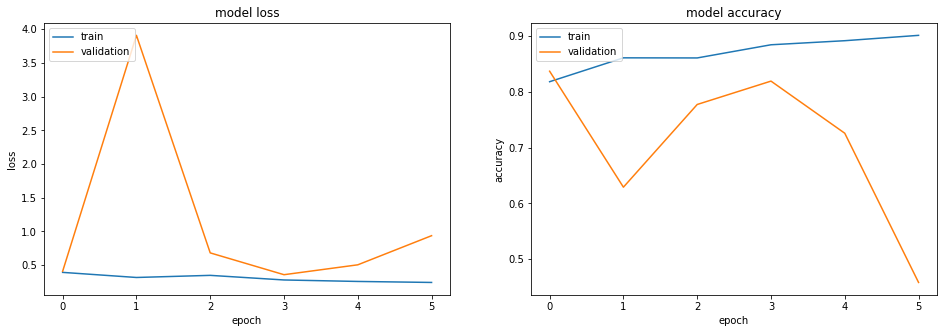

In [ ]:
plt.figure(figsize=(16,5))

# 만들어진 모델에 대해 train dataset과 validation dataset의 loss 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

# 만들어진 모델에 대해 train dataset과 validation dataset의 accuracy 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')